ER connectivity null model
https://www.nature.com/articles/s41586-024-07968-y#code-availability

In [8]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import pickle
from collections import defaultdict
import random


In [13]:
def create_erdos_renyi_null(adjacency_matrix, preserve_weights=True, n_iterations=1000):
    """
    Create Erdős–Rényi null model that preserves basic network properties
    
    Parameters:
    - adjacency_matrix: original weighted adjacency matrix
    - preserve_weights: if True, randomly reassign actual weights; if False, use binary
    - n_iterations: number of null networks to generate
    
    Returns:
    - null_networks: list of null adjacency matrices
    - null_stats: statistics from null networks
    """
    n_nodes = adjacency_matrix.shape[0]
    
    # Calculate basic properties to preserve
    total_connections = np.sum(adjacency_matrix > 0)
    connection_probability = total_connections / (n_nodes * (n_nodes - 1))  # exclude diagonal
    
    print(f"Original network properties:")
    print(f"- Nodes: {n_nodes}")
    print(f"- Total connections: {total_connections}")
    print(f"- Connection probability: {connection_probability:.4f}")
    
    if preserve_weights:
        # Get all non-zero weights for redistribution
        all_weights = adjacency_matrix[adjacency_matrix > 0]
        print(f"- Weight distribution: mean={np.mean(all_weights):.2f}, std={np.std(all_weights):.2f}")
    
    null_networks = []
    null_reciprocal_counts = []
    null_mean_strengths = []
    
    for i in range(n_iterations):
        # Create random connectivity matrix
        # Generate random matrix and threshold by connection probability
        random_matrix = np.random.random((n_nodes, n_nodes))
        null_binary = (random_matrix < connection_probability).astype(int)
        
        # Remove self-connections (set diagonal to 0)
        np.fill_diagonal(null_binary, 0)
        
        if preserve_weights:
            # Randomly redistribute the original weights
            null_weighted = null_binary.copy().astype(float)
            connection_indices = np.where(null_binary > 0)
            n_connections = len(connection_indices[0])
            
            if n_connections > 0:
                # Randomly sample weights (with replacement) from original distribution
                random_weights = np.random.choice(all_weights, size=n_connections, replace=True)
                null_weighted[connection_indices] = random_weights
        else:
            null_weighted = null_binary.astype(float)
        
        null_networks.append(null_weighted)
        
        # Calculate statistics for this null network
        null_recip_matrix = get_reciprocal_matrix(null_weighted)
        null_reciprocal_counts.append(np.sum(null_recip_matrix))
        null_mean_strengths.append(np.mean(null_weighted[null_weighted > 0]) if np.any(null_weighted > 0) else 0)
        
        if (i + 1) % 100 == 0:
            print(f"Generated {i + 1}/{n_iterations} null networks...")
    
    null_stats = {
        'reciprocal_counts': null_reciprocal_counts,
        'mean_strengths': null_mean_strengths,
        'connection_probability': connection_probability
    }
    
    return null_networks, null_stats

def get_reciprocal_matrix(adj_matrix, threshold=0):
    """Create reciprocal matrix from adjacency matrix"""
    binary_adj = (adj_matrix > threshold).astype(int)
    reciprocal = binary_adj & binary_adj.T
    return reciprocal

def compare_to_null(real_adjacency, real_reciprocal, null_networks, cell_type_indices, cell_types):
    """
    Compare real network properties to null model
    """
    # Calculate real network statistics
    real_reciprocal_count = np.sum(real_reciprocal)
    real_mean_strength = np.mean(real_adjacency[real_adjacency > 0])
    
    # Calculate null network statistics
    null_reciprocal_counts = []
    null_mean_strengths = []
    null_connection_strengths = {ct1: {ct2: [] for ct2 in cell_types} for ct1 in cell_types}
    
    print("Analyzing null networks...")
    for i, null_adj in enumerate(null_networks):
        null_recip = get_reciprocal_matrix(null_adj)
        null_reciprocal_counts.append(np.sum(null_recip))
        null_mean_strengths.append(np.mean(null_adj[null_adj > 0]) if np.any(null_adj > 0) else 0)
        
        # Calculate connection strengths for each cell type pair
        for ct1 in cell_types:
            for ct2 in cell_types:
                start1, end1 = cell_type_indices[ct1]
                start2, end2 = cell_type_indices[ct2]
                
                adj_block = null_adj[start1:end1, start2:end2]
                recip_block = null_recip[start1:end1, start2:end2]
                
                # Get reciprocal strengths
                recip_mask = (recip_block == 1) & (adj_block > 0)
                recip_strengths = adj_block[recip_mask]
                recip_mean = np.mean(recip_strengths) if len(recip_strengths) > 0 else 0
                
                null_connection_strengths[ct1][ct2].append(recip_mean)
        
        if (i + 1) % 100 == 0:
            print(f"Analyzed {i + 1}/{len(null_networks)} null networks...")
    
    # Calculate p-values
    reciprocal_p_value = np.mean(np.array(null_reciprocal_counts) >= real_reciprocal_count)
    strength_p_value = np.mean(np.array(null_mean_strengths) >= real_mean_strength)
    
    print(f"\nComparison Results:")
    print(f"Real reciprocal connections: {real_reciprocal_count}")
    print(f"Null reciprocal connections: {np.mean(null_reciprocal_counts):.1f} ± {np.std(null_reciprocal_counts):.1f}")
    print(f"P-value (reciprocal count): {reciprocal_p_value:.4f}")
    print(f"\nReal mean strength: {real_mean_strength:.2f}")
    print(f"Null mean strength: {np.mean(null_mean_strengths):.2f} ± {np.std(null_mean_strengths):.2f}")
    print(f"P-value (mean strength): {strength_p_value:.4f}")
    
    return {
        'null_reciprocal_counts': null_reciprocal_counts,
        'null_mean_strengths': null_mean_strengths,
        'null_connection_strengths': null_connection_strengths,
        'reciprocal_p_value': reciprocal_p_value,
        'strength_p_value': strength_p_value
    }

def plot_null_comparison(real_adjacency, real_reciprocal, comparison_results):
    """Plot comparison between real and null networks"""
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Plot 1: Reciprocal connection counts
    ax1 = axes[0]
    null_counts = comparison_results['null_reciprocal_counts']
    real_count = np.sum(real_reciprocal)
    
    ax1.hist(null_counts, bins=50, alpha=0.7, density=True, label='Null model')
    ax1.axvline(real_count, color='red', linestyle='--', linewidth=2, label=f'Real network ({real_count})')
    ax1.set_xlabel('Number of Reciprocal Connections')
    ax1.set_ylabel('Density')
    ax1.set_title('Reciprocal Connections: Real vs Null')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Mean connection strengths
    ax2 = axes[1]
    null_strengths = comparison_results['null_mean_strengths']
    real_strength = np.mean(real_adjacency[real_adjacency > 0])
    
    ax2.hist(null_strengths, bins=50, alpha=0.7, density=True, label='Null model')
    ax2.axvline(real_strength, color='red', linestyle='--', linewidth=2, label=f'Real network ({real_strength:.2f})')
    ax2.set_xlabel('Mean Connection Strength')
    ax2.set_ylabel('Density')
    ax2.set_title('Connection Strength: Real vs Null')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [11]:
# Load the matrices
adjacency = np.load('adjacency_binary_ordered.npy')
adjacency_weighted = np.load('adjacency_weighted_ordered.npy')

print(f"Loaded adjacency matrix shape: {adjacency.shape}")
print(f"Loaded weighted adjacency matrix shape: {adjacency_weighted.shape}")

Loaded adjacency matrix shape: (1353, 1353)
Loaded weighted adjacency matrix shape: (1353, 1353)


In [7]:
sum(sum(adjacency_weighted))

np.float64(141415.0)

In [9]:
reciprocal_matrix = np.load('reciprocal_matrix.npy')
with open('cell_type_indices.pkl', 'rb') as f:
    cell_type_indices = pickle.load(f)
with open('cell_types.pkl', 'rb') as f:
    cell_types = pickle.load(f)

print(reciprocal_matrix.shape)
print(cell_type_indices, cell_types)

(1353, 1353)
{'23P': (0, 349), '4P': (349, 614), '5P-IT': (614, 751), '5P-NP': (751, 761), '5P-PT': (761, 799), '6P-CT': (799, 942), '6P-IT': (942, 1134), '6P-U': (1134, 1162), 'BC': (1162, 1221), 'BPC': (1221, 1254), 'MC': (1254, 1295), 'NGC': (1295, 1312), 'Unsure': (1312, 1315), 'Unsure E': (1315, 1320), 'Unsure I': (1320, 1333), 'WM-P': (1333, 1353)} ['23P', '4P', '5P-IT', '5P-NP', '5P-PT', '6P-CT', '6P-IT', '6P-U', 'BC', 'BPC', 'MC', 'NGC', 'Unsure', 'Unsure E', 'Unsure I', 'WM-P']


Generating Erdős–Rényi null model...
Original network properties:
- Nodes: 1353
- Total connections: 75284
- Connection probability: 0.0412
- Weight distribution: mean=1.00, std=0.00
Generated 100/1000 null networks...
Generated 200/1000 null networks...
Generated 300/1000 null networks...
Generated 400/1000 null networks...
Generated 500/1000 null networks...
Generated 600/1000 null networks...
Generated 700/1000 null networks...
Generated 800/1000 null networks...
Generated 900/1000 null networks...
Generated 1000/1000 null networks...
Analyzing null networks...
Analyzed 100/1000 null networks...
Analyzed 200/1000 null networks...
Analyzed 300/1000 null networks...
Analyzed 400/1000 null networks...
Analyzed 500/1000 null networks...
Analyzed 600/1000 null networks...
Analyzed 700/1000 null networks...
Analyzed 800/1000 null networks...
Analyzed 900/1000 null networks...
Analyzed 1000/1000 null networks...

Comparison Results:
Real reciprocal connections: 19126
Null reciprocal connec

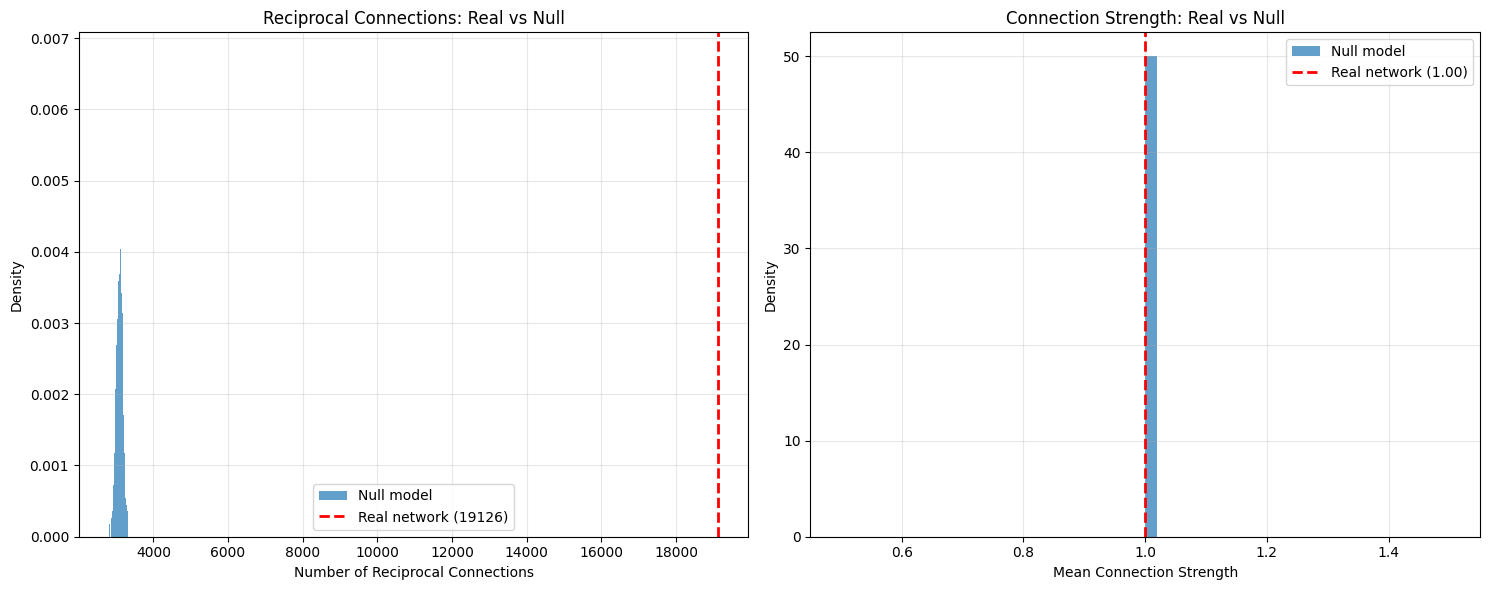

In [5]:
# Example usage:
# Generate null model
print("Generating Erdős–Rényi null model...")
null_networks, null_stats = create_erdos_renyi_null(
    adjacency, 
    preserve_weights=True, 
    n_iterations=1000
)

# Compare to real network
comparison_results = compare_to_null(
    adjacency, 
    reciprocal_matrix, 
    null_networks, 
    cell_type_indices, 
    cell_types
)

# Plot comparison
plot_null_comparison(adjacency, reciprocal_matrix, comparison_results)

Experimental set-up for more models and simulations

In [15]:
# =============================================================================
# UTILITY FUNCTIONS
# =============================================================================

def get_reciprocal_matrix(adj_matrix, threshold=0):
    """Create reciprocal matrix from adjacency matrix"""
    binary_adj = (adj_matrix > threshold).astype(int)
    reciprocal = binary_adj & binary_adj.T
    return reciprocal

def calculate_network_stats(adjacency_matrix):
    """Calculate basic network statistics"""
    reciprocal_matrix = get_reciprocal_matrix(adjacency_matrix)
    
    stats = {
        'n_nodes': adjacency_matrix.shape[0],
        'n_edges': np.sum(adjacency_matrix > 0),
        'n_reciprocal': np.sum(reciprocal_matrix),
        'mean_strength': np.mean(adjacency_matrix[adjacency_matrix > 0]) if np.any(adjacency_matrix > 0) else 0,
        'connection_probability': np.sum(adjacency_matrix > 0) / (adjacency_matrix.shape[0] * (adjacency_matrix.shape[0] - 1))
    }
    return stats

def get_edge_weights(adjacency_matrix):
    """Extract all non-zero edge weights"""
    return adjacency_matrix[adjacency_matrix > 0]

In [2]:
# =============================================================================
# NULL MODEL GENERATORS
# =============================================================================

def create_erdos_renyi_model(adjacency_matrix, preserve_weights=True, **kwargs):
    """
    Create standard Erdős–Rényi null model
    
    Parameters:
    - adjacency_matrix: original weighted adjacency matrix
    - preserve_weights: if True, randomly reassign actual weights; if False, use binary
    
    Returns:
    - null adjacency matrix
    """
    n_nodes = adjacency_matrix.shape[0]
    
    # Calculate connection probability
    total_connections = np.sum(adjacency_matrix > 0)
    connection_probability = total_connections / (n_nodes * (n_nodes - 1))
    
    # Create random connectivity matrix
    random_matrix = np.random.random((n_nodes, n_nodes))
    null_binary = (random_matrix < connection_probability).astype(int)
    
    # Remove self-connections
    np.fill_diagonal(null_binary, 0)
    
    if preserve_weights:
        # Randomly redistribute the original weights
        null_weighted = null_binary.copy().astype(float)
        connection_indices = np.where(null_binary > 0)
        n_connections = len(connection_indices[0])
        
        if n_connections > 0:
            all_weights = get_edge_weights(adjacency_matrix)
            random_weights = np.random.choice(all_weights, size=n_connections, replace=True)
            null_weighted[connection_indices] = random_weights
    else:
        null_weighted = null_binary.astype(float)
    
    return null_weighted

def create_generalized_er_model(adjacency_matrix, preserve_weights=True, **kwargs):
    """
    Create generalized ER model that preserves reciprocal edge count
    Based on the paper's approach with p^uni and p^bi parameters
    
    Parameters:
    - adjacency_matrix: original weighted adjacency matrix
    - preserve_weights: if True, randomly reassign actual weights; if False, use binary
    
    Returns:
    - null adjacency matrix
    """
    n_nodes = adjacency_matrix.shape[0]
    
    # Calculate edge statistics from real network
    binary_adj = (adjacency_matrix > 0).astype(int)
    reciprocal_matrix = get_reciprocal_matrix(adjacency_matrix)
    
    # Count unidirectional and bidirectional edges
    total_edges = np.sum(binary_adj)
    reciprocal_edges = np.sum(reciprocal_matrix)
    unidirectional_edges = total_edges - reciprocal_edges
    
    # Calculate possible edge pairs (excluding diagonal)
    total_possible_pairs = n_nodes * (n_nodes - 1) // 2
    
    # Calculate probabilities
    p_bi = reciprocal_edges / (2 * total_possible_pairs)  # bidirectional probability
    p_uni = unidirectional_edges / (n_nodes * (n_nodes - 1))  # unidirectional probability
    
    print(f"Generalized ER: p_uni = {p_uni:.6f}, p_bi = {p_bi:.6f}")
    
    # Generate null network
    null_adj = np.zeros((n_nodes, n_nodes))
    
    # For each pair of nodes (i,j) where i < j
    for i in range(n_nodes):
        for j in range(i + 1, n_nodes):
            rand = np.random.random()
            
            if rand < p_bi:
                # Create bidirectional connection
                null_adj[i, j] = 1
                null_adj[j, i] = 1
            elif rand < p_bi + 2 * p_uni:
                # Create unidirectional connection (randomly choose direction)
                if np.random.random() < 0.5:
                    null_adj[i, j] = 1
                else:
                    null_adj[j, i] = 1
    
    if preserve_weights:
        # Randomly redistribute the original weights
        connection_indices = np.where(null_adj > 0)
        n_connections = len(connection_indices[0])
        
        if n_connections > 0:
            all_weights = get_edge_weights(adjacency_matrix)
            random_weights = np.random.choice(all_weights, size=n_connections, replace=True)
            null_adj[connection_indices] = random_weights
    
    return null_adj

def create_degree_preserving_model(adjacency_matrix, n_swaps=None, preserve_weights=True, **kwargs):
    """
    Create degree-preserving null model using edge swapping (Maslov-Sneppén algorithm)
    Equivalent to Configuration Model (CFG) mentioned in the paper
    
    Parameters:
    - adjacency_matrix: original weighted adjacency matrix
    - n_swaps: number of edge swaps (default: 10x number of edges)
    - preserve_weights: whether to preserve edge weights
    
    Returns:
    - rewired adjacency matrix
    """
    adj = adjacency_matrix.copy()
    n_nodes = adj.shape[0]
    
    # Get all edges
    edges = list(zip(*np.where(adj > 0)))
    n_edges = len(edges)
    
    if n_swaps is None:
        n_swaps = 10 * n_edges  # Paper uses 1000 iterations, we scale by network size
    
    successful_swaps = 0
    attempts = 0
    max_attempts = n_swaps * 10  # Prevent infinite loops
    
    while successful_swaps < n_swaps and attempts < max_attempts:
        attempts += 1
        
        # Randomly select two edges
        if len(edges) < 2:
            break
            
        edge_indices = random.sample(range(len(edges)), 2)
        edge1_idx, edge2_idx = edge_indices
        
        # Get the edges
        i, j = edges[edge1_idx]  # edge i->j
        k, l = edges[edge2_idx]  # edge k->l
        
        # Switch-and-hold: swap target endpoints
        # Check if we can swap: i->l and k->j (avoid self-loops and multiple edges)
        if (i != l and k != j and i != k and j != l and
            adj[i, l] == 0 and adj[k, j] == 0):
            
            # Store weights if preserving them
            if preserve_weights:
                weight_ij = adj[i, j]
                weight_kl = adj[k, l]
            else:
                weight_ij = weight_kl = 1
            
            # Perform the swap
            adj[i, j] = 0
            adj[k, l] = 0
            adj[i, l] = weight_ij
            adj[k, j] = weight_kl
            
            # Update edges list
            edges[edge1_idx] = (i, l)
            edges[edge2_idx] = (k, j)
            
            successful_swaps += 1
    
    return adj

def create_cell_type_preserving_model(adjacency_matrix, cell_type_indices, cell_types,
                                    preserve_within_type=True, preserve_weights=True, **kwargs):
    """
    Create cell-type preserving null model
    
    Parameters:
    - adjacency_matrix: original weighted adjacency matrix
    - cell_type_indices: dictionary mapping cell types to (start, end) indices
    - cell_types: list of cell type names
    - preserve_within_type: if True, preserve within-cell-type connectivity exactly
    - preserve_weights: whether to preserve edge weights
    
    Returns:
    - cell-type preserving adjacency matrix
    """
    adj = np.zeros_like(adjacency_matrix)
    
    for ct1 in cell_types:
        start1, end1 = cell_type_indices[ct1]
        
        for ct2 in cell_types:
            start2, end2 = cell_type_indices[ct2]
            
            # Get the block between these cell types
            original_block = adjacency_matrix[start1:end1, start2:end2]
            
            if preserve_within_type and ct1 == ct2:
                # Keep within-cell-type connectivity exactly as is
                adj[start1:end1, start2:end2] = original_block
            else:
                # Randomize between-cell-type connectivity
                nonzero_weights = original_block[original_block > 0]
                
                if len(nonzero_weights) > 0:
                    # Calculate connection probability for this block
                    block_size = original_block.size
                    n_connections = len(nonzero_weights)
                    connection_prob = n_connections / block_size
                    
                    # Create random connectivity pattern
                    random_pattern = np.random.random(original_block.shape) < connection_prob
                    
                    if preserve_weights:
                        # Randomly redistribute the original weights
                        random_weights = np.random.choice(nonzero_weights, 
                                                        size=np.sum(random_pattern), 
                                                        replace=True)
                        new_block = np.zeros_like(original_block, dtype=float)
                        new_block[random_pattern] = random_weights
                    else:
                        new_block = random_pattern.astype(float)
                    
                    adj[start1:end1, start2:end2] = new_block
    
    return adj

In [3]:
# =============================================================================
# SIMULATION FRAMEWORK
# =============================================================================

def simulate_null_models(real_adjacency, model_configs, n_iterations=100, verbose=True):
    """
    Simulate multiple null models
    
    Parameters:
    - real_adjacency: original adjacency matrix
    - model_configs: dictionary of model configurations
      Example: {
          'erdos_renyi': {'func': create_erdos_renyi_model, 'preserve_weights': True},
          'degree_preserving': {'func': create_degree_preserving_model, 'n_swaps': 10000}
      }
    - n_iterations: number of iterations per model
    - verbose: whether to print progress
    
    Returns:
    - results: dictionary with simulation results for each model
    """
    results = {}
    
    for model_name, config in model_configs.items():
        if verbose:
            print(f"Simulating {model_name} model...")
        
        model_func = config['func']
        model_params = {k: v for k, v in config.items() if k != 'func'}
        
        model_results = {
            'reciprocal_counts': [],
            'mean_strengths': [],
            'n_edges': [],
            'connection_probabilities': []
        }
        
        for i in range(n_iterations):
            if verbose and (i + 1) % (n_iterations // 4) == 0:
                print(f"  Iteration {i + 1}/{n_iterations}")
            
            # Generate null model
            null_adj = model_func(real_adjacency, **model_params)
            
            # Calculate statistics
            null_reciprocal = get_reciprocal_matrix(null_adj)
            model_results['reciprocal_counts'].append(np.sum(null_reciprocal))
            model_results['mean_strengths'].append(
                np.mean(null_adj[null_adj > 0]) if np.any(null_adj > 0) else 0
            )
            model_results['n_edges'].append(np.sum(null_adj > 0))
            model_results['connection_probabilities'].append(
                np.sum(null_adj > 0) / (null_adj.shape[0] * (null_adj.shape[0] - 1))
            )
        
        results[model_name] = model_results
        
        if verbose:
            mean_recip = np.mean(model_results['reciprocal_counts'])
            std_recip = np.std(model_results['reciprocal_counts'])
            print(f"  {model_name}: {mean_recip:.1f} ± {std_recip:.1f} reciprocal connections")
    
    return results

In [4]:
# =============================================================================
# COMPARISON AND ANALYSIS
# =============================================================================

def compare_models_to_real(real_adjacency, simulation_results, metrics=['reciprocal_counts', 'mean_strengths']):
    """
    Compare simulation results to real network
    
    Parameters:
    - real_adjacency: original adjacency matrix
    - simulation_results: results from simulate_null_models
    - metrics: list of metrics to compare
    
    Returns:
    - comparison_results: dictionary with p-values and effect sizes
    """
    real_stats = calculate_network_stats(real_adjacency)
    
    # Map metrics to real values
    real_values = {
        'reciprocal_counts': real_stats['n_reciprocal'],
        'mean_strengths': real_stats['mean_strength'],
        'n_edges': real_stats['n_edges'],
        'connection_probabilities': real_stats['connection_probability']
    }
    
    comparison_results = {}
    
    for model_name, model_results in simulation_results.items():
        model_comparison = {}
        
        for metric in metrics:
            if metric in model_results and metric in real_values:
                null_values = np.array(model_results[metric])
                real_value = real_values[metric]
                
                # Calculate p-value (two-tailed)
                p_value_greater = np.mean(null_values >= real_value)
                p_value_lesser = np.mean(null_values <= real_value)
                p_value = 2 * min(p_value_greater, p_value_lesser)
                
                # Calculate effect size (Cohen's d)
                null_mean = np.mean(null_values)
                null_std = np.std(null_values)
                cohens_d = (real_value - null_mean) / null_std if null_std > 0 else np.inf
                
                model_comparison[metric] = {
                    'real_value': real_value,
                    'null_mean': null_mean,
                    'null_std': null_std,
                    'p_value': p_value,
                    'p_value_greater': p_value_greater,
                    'cohens_d': cohens_d
                }
        
        comparison_results[model_name] = model_comparison
    
    return comparison_results

In [5]:
# =============================================================================
# PLOTTING FUNCTIONS
# =============================================================================

def plot_model_comparison(real_adjacency, simulation_results, comparison_results, 
                         metrics=['reciprocal_counts', 'mean_strengths'], figsize=(16, 12)):
    """
    Plot comparison of null models
    
    Parameters:
    - real_adjacency: original adjacency matrix
    - simulation_results: results from simulate_null_models
    - comparison_results: results from compare_models_to_real
    - metrics: list of metrics to plot
    - figsize: figure size
    """
    n_metrics = len(metrics)
    n_models = len(simulation_results)
    
    fig, axes = plt.subplots(n_metrics, 2, figsize=figsize)
    if n_metrics == 1:
        axes = axes.reshape(1, -1)
    
    # Colors for different models
    colors = plt.cm.Set3(np.linspace(0, 1, n_models))
    model_names = list(simulation_results.keys())
    
    # Real network stats
    real_stats = calculate_network_stats(real_adjacency)
    real_values = {
        'reciprocal_counts': real_stats['n_reciprocal'],
        'mean_strengths': real_stats['mean_strength'],
        'n_edges': real_stats['n_edges'],
        'connection_probabilities': real_stats['connection_probability']
    }
    
    metric_labels = {
        'reciprocal_counts': 'Number of Reciprocal Connections',
        'mean_strengths': 'Mean Connection Strength',
        'n_edges': 'Number of Edges',
        'connection_probabilities': 'Connection Probability'
    }
    
    for i, metric in enumerate(metrics):
        # Left plot: Distributions
        ax_left = axes[i, 0]
        
        for j, model_name in enumerate(model_names):
            values = simulation_results[model_name][metric]
            p_val = comparison_results[model_name][metric]['p_value_greater']
            
            ax_left.hist(values, bins=30, alpha=0.6, density=True,
                        label=f"{model_name} (p={p_val:.4f})",
                        color=colors[j])
        
        real_val = real_values[metric]
        ax_left.axvline(real_val, color='red', linestyle='--', linewidth=2,
                       label=f'Real network ({real_val:.2f})')
        
        ax_left.set_xlabel(metric_labels.get(metric, metric))
        ax_left.set_ylabel('Density')
        ax_left.set_title(f'{metric_labels.get(metric, metric)}: Real vs Null Models')
        ax_left.legend()
        ax_left.grid(True, alpha=0.3)
        
        # Right plot: P-values
        ax_right = axes[i, 1]
        p_vals = [comparison_results[model][metric]['p_value_greater'] for model in model_names]
        
        bars = ax_right.bar(range(len(model_names)), p_vals,
                           color=colors, alpha=0.7)
        ax_right.axhline(0.05, color='red', linestyle='--', alpha=0.7, label='α = 0.05')
        ax_right.set_xticks(range(len(model_names)))
        ax_right.set_xticklabels(model_names, rotation=45)
        ax_right.set_ylabel('P-value')
        ax_right.set_title(f'P-values: {metric_labels.get(metric, metric)}')
        ax_right.legend()
        ax_right.grid(True, alpha=0.3)
        
        # Add value labels on bars
        for bar, p_val in zip(bars, p_vals):
            height = bar.get_height()
            ax_right.text(bar.get_x() + bar.get_width()/2., height + 0.005,
                         f'{p_val:.4f}', ha='center', va='bottom', fontsize=10)
    
    plt.tight_layout()
    plt.show()

def print_comparison_summary(comparison_results):
    """Print summary of null model comparisons"""
    print("\nNull Model Comparison Summary:")
    print("=" * 80)
    
    for model_name, model_results in comparison_results.items():
        print(f"\n{model_name.replace('_', ' ').title()}:")
        print("-" * 40)
        
        for metric, stats in model_results.items():
            real_val = stats['real_value']
            null_mean = stats['null_mean']
            null_std = stats['null_std']
            p_val = stats['p_value_greater']
            cohens_d = stats['cohens_d']
            
            print(f"  {metric}:")
            print(f"    Real value: {real_val:.2f}")
            print(f"    Null model: {null_mean:.2f} ± {null_std:.2f}")
            print(f"    P-value: {p_val:.4f}")
            print(f"    Effect size (Cohen's d): {cohens_d:.2f}")
            
            if p_val < 0.001:
                significance = "***"
            elif p_val < 0.01:
                significance = "**"
            elif p_val < 0.05:
                significance = "*"
            else:
                significance = "ns"
            
            print(f"    Significance: {significance}")
            print()

Running null model analysis with 4 models...
Models: ['erdos_renyi', 'generalized_er', 'degree_preserving', 'cell_type_preserving']
Simulating erdos_renyi model...
  Iteration 2/10
  Iteration 4/10
  Iteration 6/10
  Iteration 8/10
  Iteration 10/10
  erdos_renyi: 3089.4 ± 95.9 reciprocal connections
Simulating generalized_er model...
Generalized ER: p_uni = 0.030700, p_bi = 0.010456
  Iteration 2/10
Generalized ER: p_uni = 0.030700, p_bi = 0.010456
Generalized ER: p_uni = 0.030700, p_bi = 0.010456
  Iteration 4/10
Generalized ER: p_uni = 0.030700, p_bi = 0.010456
Generalized ER: p_uni = 0.030700, p_bi = 0.010456
  Iteration 6/10
Generalized ER: p_uni = 0.030700, p_bi = 0.010456
Generalized ER: p_uni = 0.030700, p_bi = 0.010456
  Iteration 8/10
Generalized ER: p_uni = 0.030700, p_bi = 0.010456
Generalized ER: p_uni = 0.030700, p_bi = 0.010456
  Iteration 10/10
Generalized ER: p_uni = 0.030700, p_bi = 0.010456
  generalized_er: 19086.6 ± 182.4 reciprocal connections
Simulating degree_pr

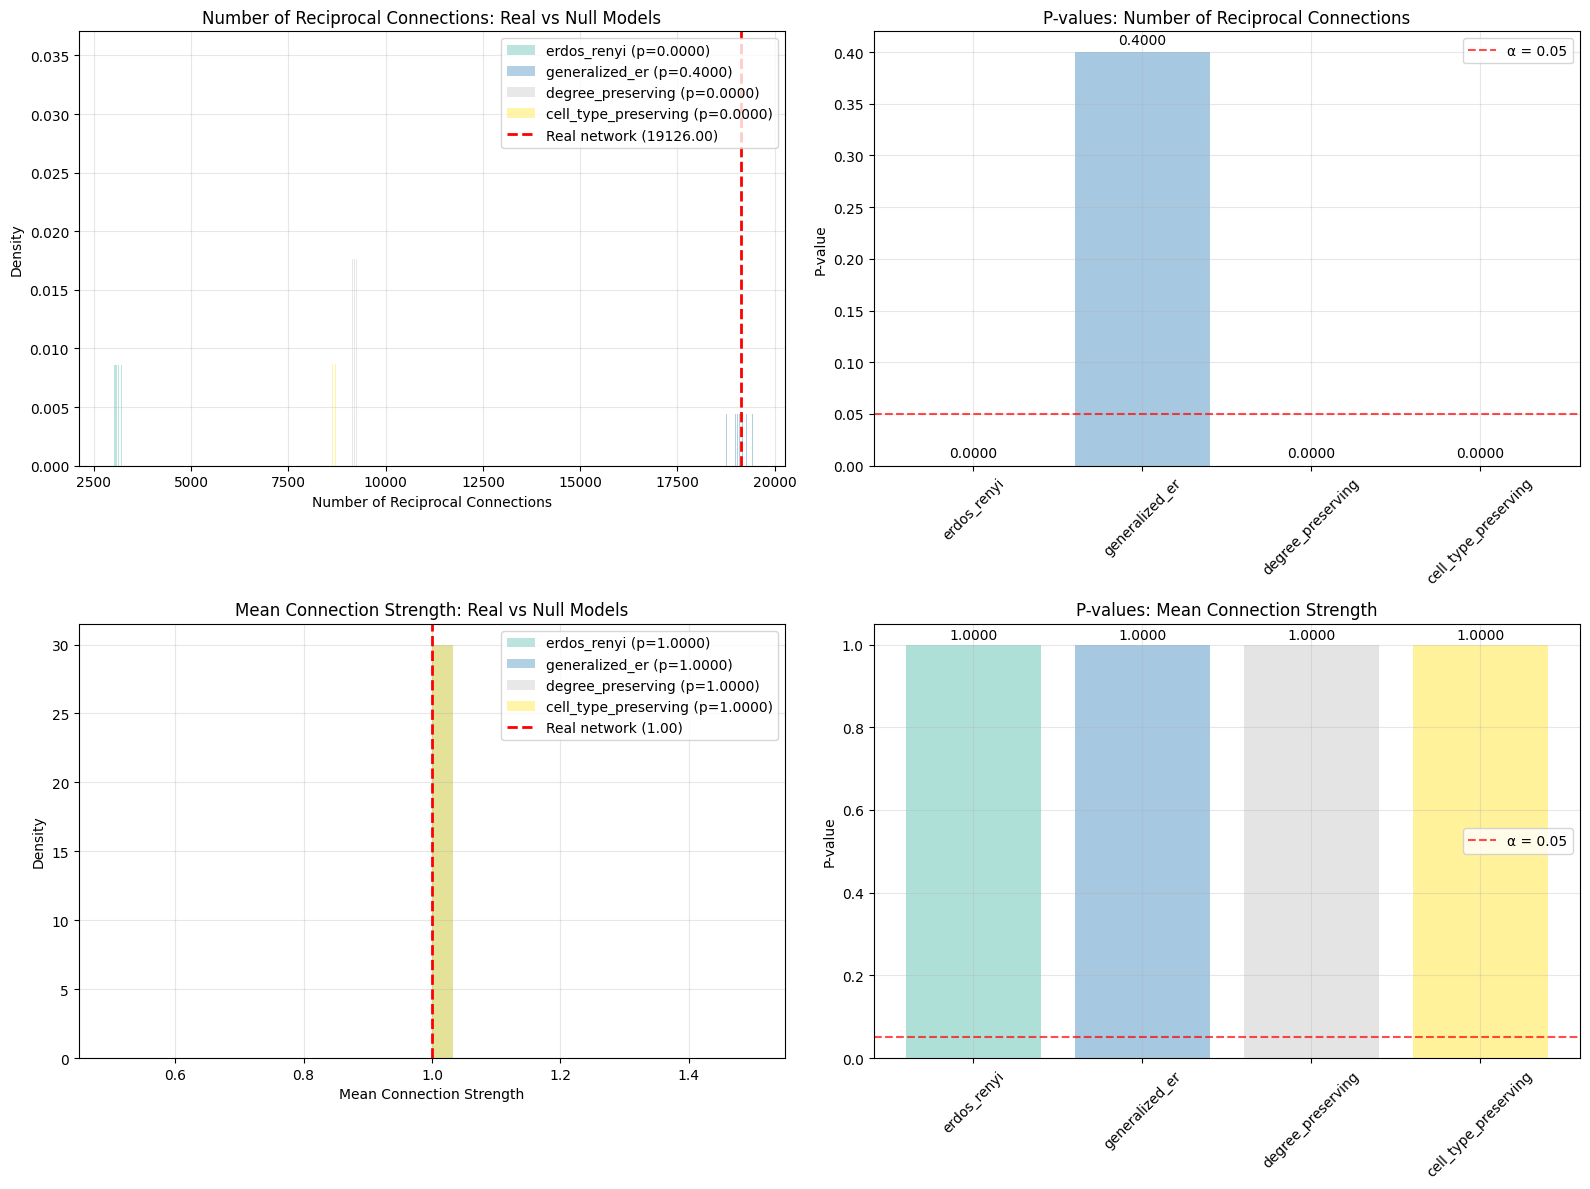

In [15]:
# =============================================================================
# EXAMPLE USAGE
# =============================================================================

def run_null_model_analysis(real_adjacency, cell_type_indices=None, cell_types=None, 
                           n_iterations=100, models_to_run=['erdos_renyi', 'degree_preserving']):
    """
    Complete null model analysis pipeline
    
    Parameters:
    - real_adjacency: original adjacency matrix
    - cell_type_indices: dictionary mapping cell types to indices (required for cell-type preserving)
    - cell_types: list of cell type names (required for cell-type preserving)
    - n_iterations: number of iterations per model
    - models_to_run: list of models to run
    
    Returns:
    - simulation_results, comparison_results
    """
    
    # Define available models
    available_models = {
        'erdos_renyi': {
            'func': create_erdos_renyi_model,
            'preserve_weights': True
        },
        'generalized_er': {
            'func': create_generalized_er_model,
            'preserve_weights': True
        },
        'degree_preserving': {
            'func': create_degree_preserving_model,
            'preserve_weights': True,
            'n_swaps': None  # Will use default
        },
        'cell_type_preserving': {
            'func': create_cell_type_preserving_model,
            'cell_type_indices': cell_type_indices,
            'cell_types': cell_types,
            'preserve_within_type': True,
            'preserve_weights': True
        }
    }
    
    # Filter models to run
    model_configs = {name: config for name, config in available_models.items() 
                    if name in models_to_run}
    
    # Check if cell type preserving is requested but parameters not provided
    if 'cell_type_preserving' in models_to_run:
        if cell_type_indices is None or cell_types is None:
            print("Warning: cell_type_preserving requires cell_type_indices and cell_types. Skipping.")
            del model_configs['cell_type_preserving']
    
    print(f"Running null model analysis with {len(model_configs)} models...")
    print(f"Models: {list(model_configs.keys())}")
    
    # Run simulations
    simulation_results = simulate_null_models(real_adjacency, model_configs, n_iterations)
    
    # Compare to real network
    comparison_results = compare_models_to_real(real_adjacency, simulation_results)
    
    # Print summary
    print_comparison_summary(comparison_results)
    
    # Plot results
    plot_model_comparison(real_adjacency, simulation_results, comparison_results)
    
    return simulation_results, comparison_results

simulation_results, comparison_results = run_null_model_analysis(
    adjacency,
    cell_type_indices=cell_type_indices,
    cell_types=cell_types,
    n_iterations=10,
    models_to_run=['erdos_renyi', 'generalized_er', 'degree_preserving', 'cell_type_preserving']
)

Simulating erdos_renyi_binary model...
  Iteration 2/10
  Iteration 4/10
  Iteration 6/10
  Iteration 8/10
  Iteration 10/10
  erdos_renyi_binary: 3128.6 ± 61.1 reciprocal connections
Simulating degree_preserving_slow model...
  Iteration 2/10
  Iteration 4/10
  Iteration 6/10
  Iteration 8/10
  Iteration 10/10
  degree_preserving_slow: 9239.8 ± 60.2 reciprocal connections
Simulating cell_type_no_within model...
  Iteration 2/10
  Iteration 4/10
  Iteration 6/10
  Iteration 8/10
  Iteration 10/10
  cell_type_no_within: 8148.9 ± 117.4 reciprocal connections
Simulating cell_type_within model...
  Iteration 2/10
  Iteration 4/10
  Iteration 6/10
  Iteration 8/10
  Iteration 10/10
  cell_type_within: 8760.2 ± 115.0 reciprocal connections


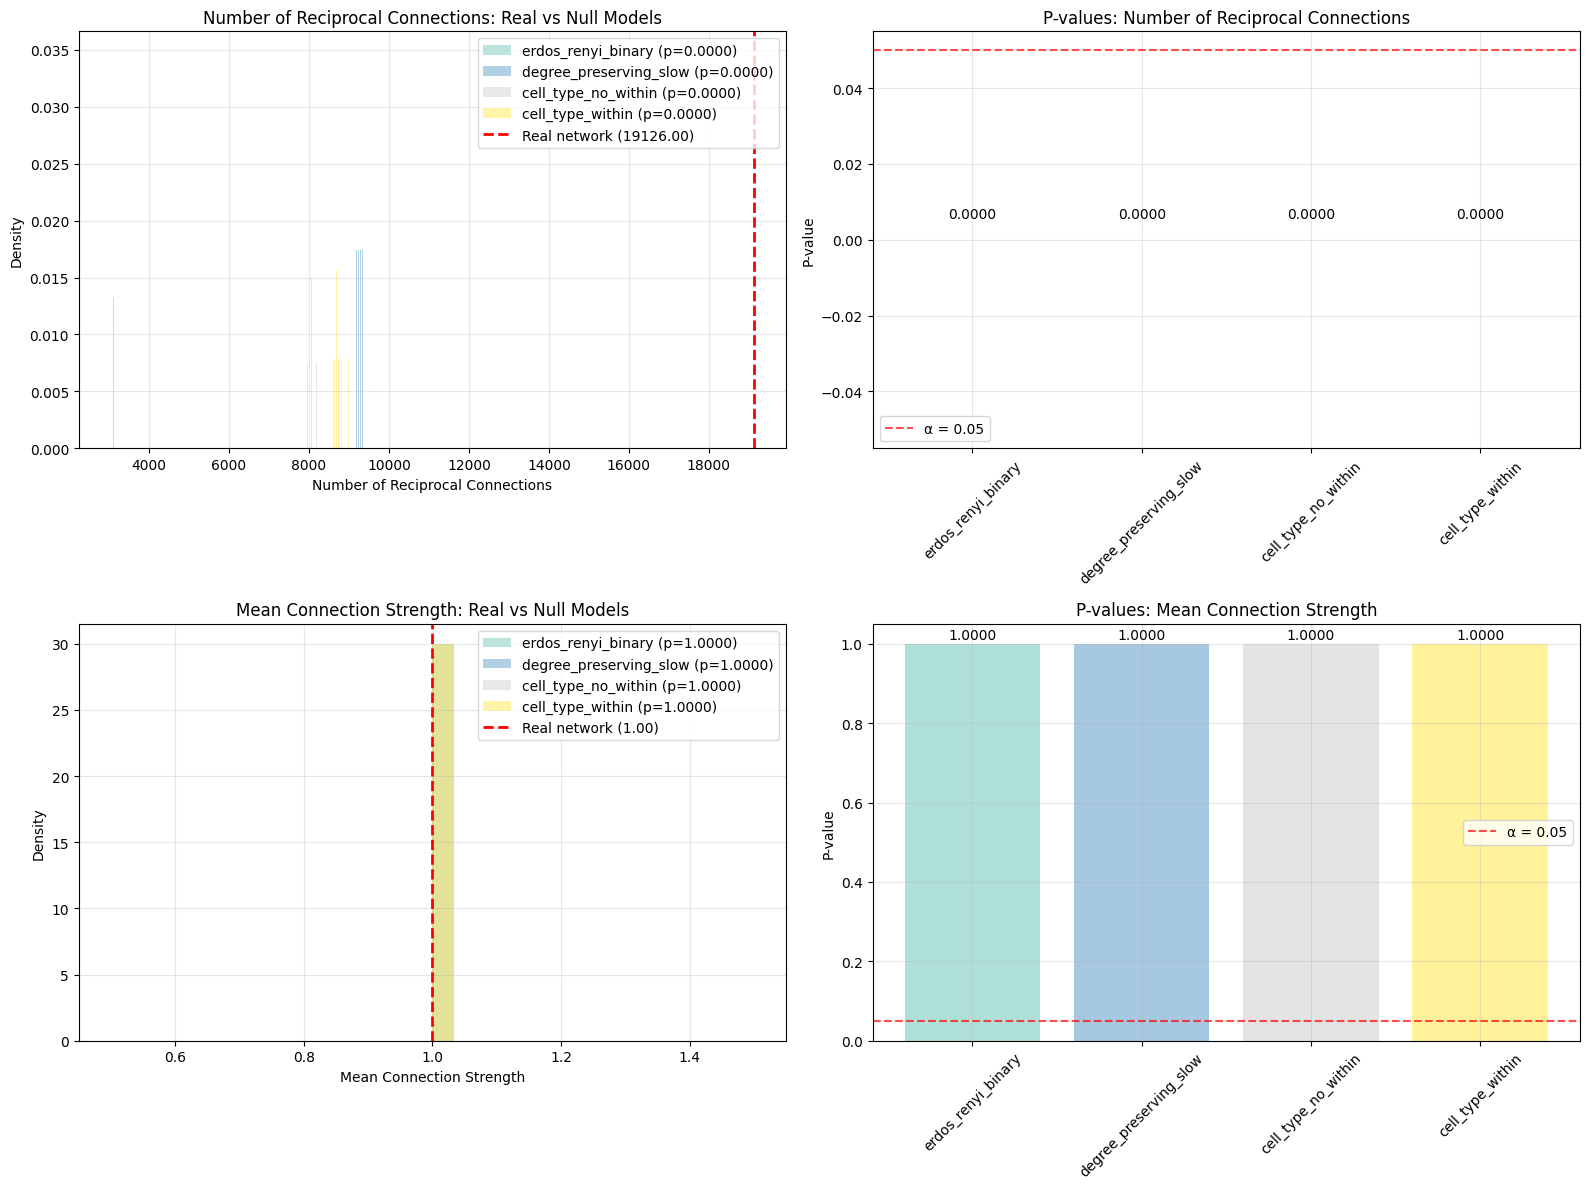

In [ ]:
# Define custom model configurations
model_configs = {
    'erdos_renyi_binary': {
        'func': create_erdos_renyi_model,
        'preserve_weights': False  # Binary version
    },
    # 'degree_preserving_fast': {
    #     'func': create_degree_preserving_model,
    #     'n_swaps': 1000,  # Fewer swaps for speed
    #     'preserve_weights': True
    # },
    'degree_preserving_slow': {
        'func': create_degree_preserving_model,
        'n_swaps': 1000000, 
        'preserve_weights': True
    },
    'cell_type_no_within': {
        'func': create_cell_type_preserving_model,
        'cell_type_indices': cell_type_indices,
        'cell_types': cell_types,
        'preserve_within_type': False,  # Randomize within-type too
        'preserve_weights': True
    },
    'cell_type_within': {
        'func': create_cell_type_preserving_model,
        'cell_type_indices': cell_type_indices,
        'cell_types': cell_types,
        'preserve_within_type': True,  # Randomize within-type too
        'preserve_weights': True
    }
}

# Run custom simulation
simulation_results = simulate_null_models(adjacency, model_configs, n_iterations=10)
comparison_results = compare_models_to_real(adjacency, simulation_results)
plot_model_comparison(adjacency, simulation_results, comparison_results)